## Univercidad de la Ciénega del Estado de Michoacán de Ocampo

## INGENIERÍA EN NANOTECNOLOGÍA

## CURSO: Modelado, simulación e inteligencia artificial

SEMESTRE 2025-2026-II

### Alumna: **Yesenia Guadalupe Zaragoza Martinez**

### Profesor: **Mtro. Luis José Yudico Anaya**

## **Tarea de la Unidad 2**

# Tarea 2: Simulación de Dinámica Molecular a Múltiples Temperaturas

## Objetivo
Repetir la simulación MD del clúster de Au₅₅ a T = 100, 300, 500, 700 K y analizar:
- Energía promedio vs Temperatura
- Coeficiente de difusión vs T (gráfica de Arrhenius)
- Función de distribución radial (RDF) a diferentes temperaturas

## 1. Importar librerías

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from ase import Atoms
from ase.cluster import Icosahedron
from ase.calculators.emt import EMT
from ase.md.langevin import Langevin
from ase.md.velocitydistribution import MaxwellBoltzmannDistribution
from ase import units
from ase.neighborlist import neighbor_list
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
print('Librerías importadas correctamente.')

Librerías importadas correctamente.


## 2. Crear el clúster de Au₅₅ (número mágico icosaédrico)

In [2]:
def create_au55_cluster():
    """Crea un clúster icosaédrico de Au con 55 átomos."""
    try:
        cluster = Icosahedron('Au', noshells=3, latticeconstant=4.08)
    except TypeError:
        try:
            cluster = Icosahedron('Au', noshells=3, lattice_constant=4.08)
        except TypeError:
            cluster = Icosahedron('Au', noshells=3)
    cluster.set_calculator(EMT())
    return cluster

au55 = create_au55_cluster()
print(f'Clúster Au₅₅ creado con {len(au55)} átomos.')
E0 = au55.get_potential_energy()
print(f'Energía potencial inicial: {E0:.4f} eV')

Clúster Au₅₅ creado con 55 átomos.
Energía potencial inicial: 29.2958 eV


## 3. Definir la función de simulación MD

In [3]:
def run_md_simulation(cluster_template, temperature_K, n_steps=2000, dt=5.0):
    from copy import deepcopy
    cluster = deepcopy(cluster_template)
    cluster.set_calculator(EMT())
    MaxwellBoltzmannDistribution(cluster, temperature_K=temperature_K)
    friction = 0.02
    dyn = Langevin(cluster, dt * units.fs, temperature_K=temperature_K, friction=friction)
    energies = []; positions_log = []; times = []
    n_equil = n_steps // 4
    dyn.run(n_equil)
    sample_freq = 10
    for step in range(0, n_steps, sample_freq):
        dyn.run(sample_freq)
        e = cluster.get_potential_energy() / len(cluster)
        energies.append(e)
        positions_log.append(cluster.get_positions().copy())
        times.append((n_equil + step) * dt)
    return {'energies': np.array(energies), 'positions': np.array(positions_log),
            'times': np.array(times), 'n_atoms': len(cluster)}

print('Función MD definida.')

Función MD definida.


## 4. Ejecutar simulaciones MD a T = 100, 300, 500 y 700 K

> **Nota:** Esta celda puede tardar varios minutos en ejecutarse.

In [4]:
TEMPERATURES = [100, 300, 500, 700]
results = {}
for T in TEMPERATURES:
    print(f'Simulando T = {T} K ...', end=' ', flush=True)
    results[T] = run_md_simulation(au55, T, n_steps=2000, dt=5.0)
    print(f'Listo.  E_prom = {results[T]["energies"].mean():.4f} eV/átomo')
print('\nTodas las simulaciones completadas.')

Simulando T = 100 K ... Listo.  E_prom = 0.3294 eV/átomo
Simulando T = 300 K ... Listo.  E_prom = 0.3556 eV/átomo
Simulando T = 500 K ... Listo.  E_prom = 0.3917 eV/átomo
Simulando T = 700 K ... Listo.  E_prom = 0.4490 eV/átomo

Todas las simulaciones completadas.


## 5. Análisis A — Energía promedio vs Temperatura

 Temperatura (K)  E promedio (eV/átomo)  Desv. estándar (eV/átomo)
             100               0.329425                   0.001478
             300               0.355587                   0.004070
             500               0.391706                   0.006855
             700               0.449018                   0.011592


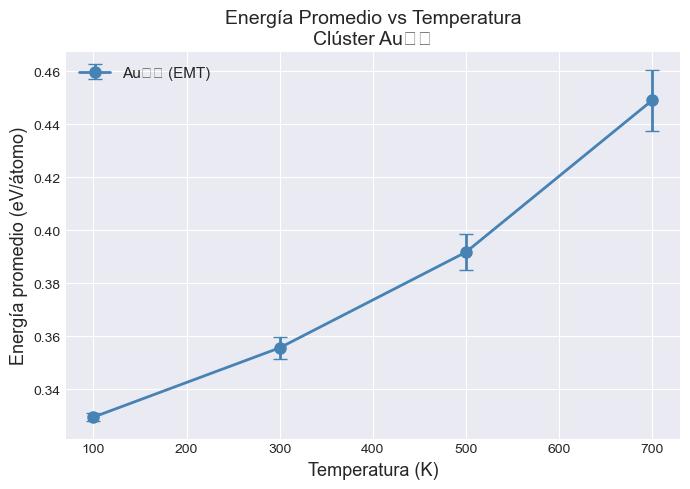

Gráfica guardada como energia_vs_temperatura.png


In [5]:
avg_energies = [results[T]['energies'].mean() for T in TEMPERATURES]
std_energies = [results[T]['energies'].std()  for T in TEMPERATURES]
df_energy = pd.DataFrame({'Temperatura (K)': TEMPERATURES,
    'E promedio (eV/átomo)': avg_energies, 'Desv. estándar (eV/átomo)': std_energies})
print(df_energy.to_string(index=False))
fig, ax = plt.subplots(figsize=(7, 5))
ax.errorbar(TEMPERATURES, avg_energies, yerr=std_energies,
            fmt='o-', color='steelblue', capsize=5, linewidth=2, markersize=8, label='Au₅₅ (EMT)')
ax.set_xlabel('Temperatura (K)', fontsize=13)
ax.set_ylabel('Energía promedio (eV/átomo)', fontsize=13)
ax.set_title('Energía Promedio vs Temperatura\nClúster Au₅₅', fontsize=14)
ax.legend(fontsize=11)
plt.tight_layout(); plt.savefig('energia_vs_temperatura.png', dpi=150); plt.show()
print('Gráfica guardada como energia_vs_temperatura.png')

## 6. Análisis B — Coeficiente de difusión (MSD) y Gráfica de Arrhenius

$$\text{MSD}(t) = 6 D t \qquad \ln(D) = \ln(D_0) - \frac{E_a}{k_B T}$$

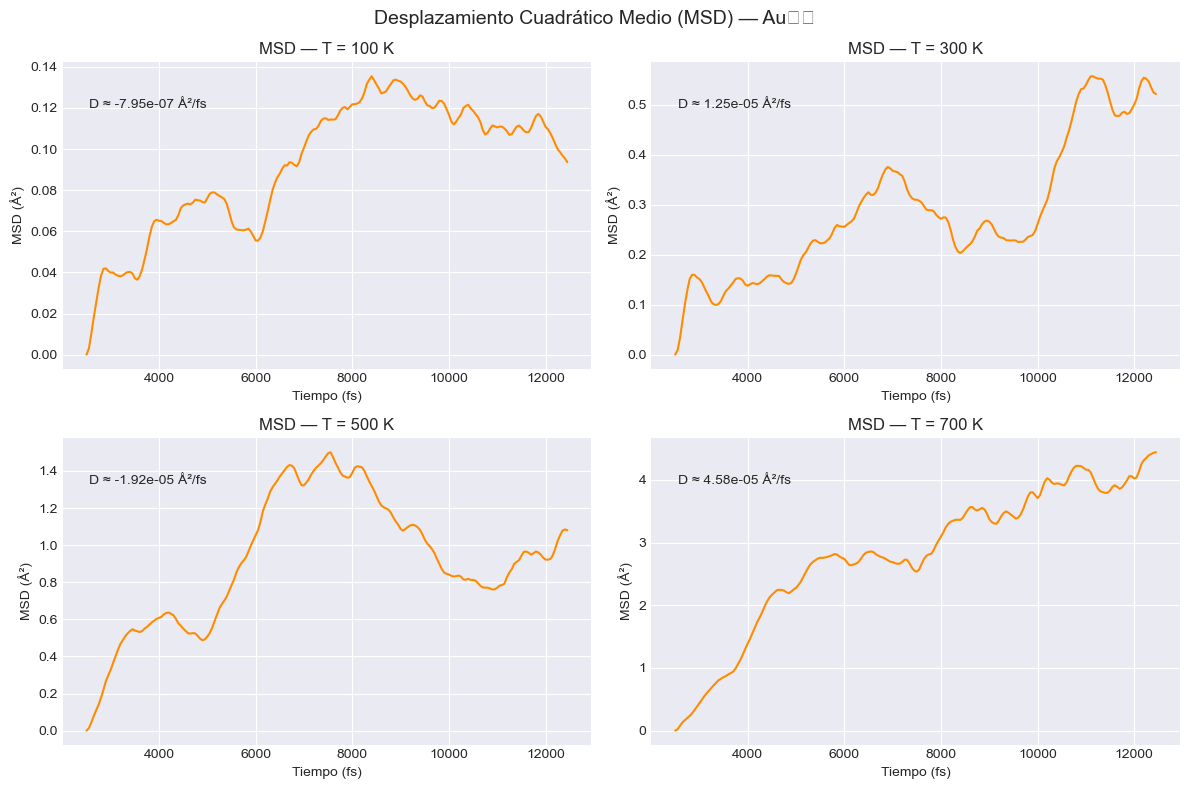

In [6]:
def compute_diffusion_coefficient(positions, times):
    r0 = positions[0]
    msd = np.mean(np.sum((positions - r0)**2, axis=2), axis=1)
    n = len(times); t_fit = times[n//2:]; m_fit = msd[n//2:]
    slope, _ = np.polyfit(t_fit, m_fit, 1)
    return slope / 6.0, msd, times

D_values = []
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
for i, T in enumerate(TEMPERATURES):
    D, msd, t = compute_diffusion_coefficient(results[T]['positions'], results[T]['times'])
    D_values.append(D)
    axes[i].plot(t, msd, color='darkorange', linewidth=1.5)
    axes[i].set_title(f'MSD — T = {T} K', fontsize=12)
    axes[i].set_xlabel('Tiempo (fs)', fontsize=10); axes[i].set_ylabel('MSD (Å²)', fontsize=10)
    axes[i].annotate(f'D ≈ {D:.2e} Å²/fs', xy=(0.05, 0.85), xycoords='axes fraction', fontsize=10)
plt.suptitle('Desplazamiento Cuadrático Medio (MSD) — Au₅₅', fontsize=14)
plt.tight_layout(); plt.savefig('msd_por_temperatura.png', dpi=150); plt.show()

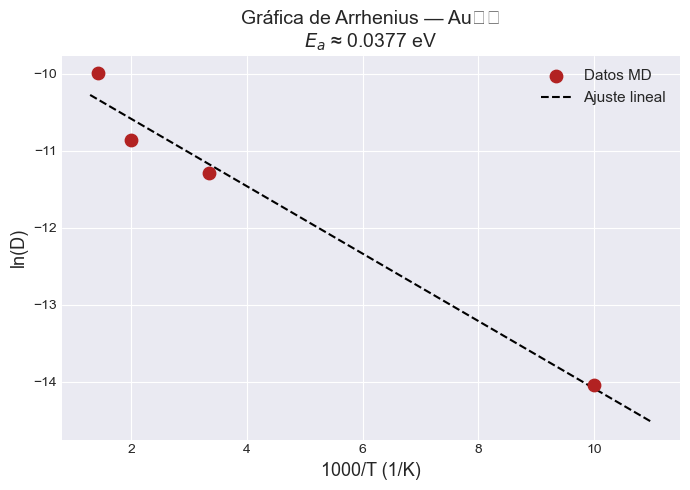

Ea ≈ 0.0377 eV  |  D₀ ≈ 6.0455e-05 Å²/fs


In [7]:
inv_T = 1.0 / np.array(TEMPERATURES); ln_D = np.log(np.abs(D_values))
slope_arr, intercept_arr = np.polyfit(inv_T, ln_D, 1)
kB = 8.617333e-5; Ea = -slope_arr * kB; D0 = np.exp(intercept_arr)
x_fit = np.linspace(inv_T.min()*0.9, inv_T.max()*1.1, 200)
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(inv_T*1e3, ln_D, color='firebrick', s=80, zorder=5, label='Datos MD')
ax.plot(x_fit*1e3, slope_arr*x_fit+intercept_arr, 'k--', linewidth=1.5, label='Ajuste lineal')
ax.set_xlabel('1000/T (1/K)', fontsize=13); ax.set_ylabel('ln(D)', fontsize=13)
ax.set_title(f'Gráfica de Arrhenius — Au₅₅\n$E_a$ ≈ {Ea:.4f} eV', fontsize=14)
ax.legend(fontsize=11)
plt.tight_layout(); plt.savefig('arrhenius.png', dpi=150); plt.show()
print(f'Ea ≈ {Ea:.4f} eV  |  D₀ ≈ {D0:.4e} Å²/fs')

## 7. Análisis C — Función de distribución radial (RDF) a distintas temperaturas

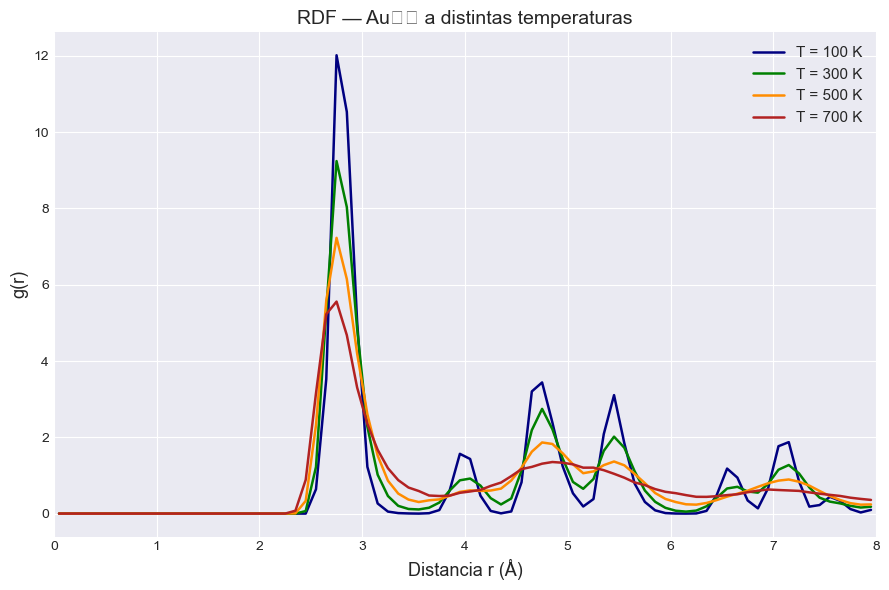

In [8]:
def compute_rdf(positions_array, r_max=8.0, n_bins=80):
    bins = np.linspace(0, r_max, n_bins+1); r_centers = 0.5*(bins[:-1]+bins[1:])
    hist_total = np.zeros(n_bins); n_frames, n_atoms, _ = positions_array.shape
    for pos in positions_array:
        diff = pos[:, np.newaxis, :] - pos[np.newaxis, :, :]
        dist = np.sqrt(np.sum(diff**2, axis=2))
        mask = ~np.eye(n_atoms, dtype=bool); r_vals = dist[mask].ravel()
        hist, _ = np.histogram(r_vals[r_vals < r_max], bins=bins); hist_total += hist
    hist_total /= (n_frames * n_atoms)
    shell_vol = (4/3)*np.pi*(bins[1:]**3 - bins[:-1]**3)
    rho = n_atoms / ((4/3)*np.pi*r_max**3)
    return r_centers, hist_total / (rho * shell_vol)

colors = ['navy','green','darkorange','firebrick']
fig, ax = plt.subplots(figsize=(9, 6))
for T, color in zip(TEMPERATURES, colors):
    r, g = compute_rdf(results[T]['positions']); ax.plot(r, g, color=color, linewidth=1.8, label=f'T = {T} K')
ax.set_xlabel('Distancia r (Å)', fontsize=13); ax.set_ylabel('g(r)', fontsize=13)
ax.set_title('RDF — Au₅₅ a distintas temperaturas', fontsize=14)
ax.legend(fontsize=11); ax.set_xlim(0, 8.0)
plt.tight_layout(); plt.savefig('rdf_temperaturas.png', dpi=150); plt.show()

## 8. Resumen de resultados

In [9]:
df_resumen = pd.DataFrame({'Temperatura (K)': TEMPERATURES,
    'E promedio (eV/átomo)': [f'{e:.4f}' for e in avg_energies],
    'σ_E (eV/átomo)': [f'{s:.4f}' for s in std_energies],
    'D (Å²/fs)': [f'{d:.2e}' for d in D_values]})
print('=== Resumen MD — Au₅₅ ==='); print(df_resumen.to_string(index=False))
print(f'\nEa ≈ {Ea:.4f} eV')
df_resumen.to_csv('resumen_md_temperaturas.csv', index=False)
print('Tabla guardada en resumen_md_temperaturas.csv')

=== Resumen MD — Au₅₅ ===
 Temperatura (K) E promedio (eV/átomo) σ_E (eV/átomo) D (Å²/fs)
             100                0.3294         0.0015 -7.95e-07
             300                0.3556         0.0041  1.25e-05
             500                0.3917         0.0069 -1.92e-05
             700                0.4490         0.0116  4.58e-05

Ea ≈ 0.0377 eV
Tabla guardada en resumen_md_temperaturas.csv


---
# Tarea 2 (Parte 2): Comparación MD vs Monte Carlo

Implementar MC canónico para Au₅₅ y comparar con MD:
- **Energía de equilibrio** · **Tiempo de equilibración** · **Eficiencia computacional**

## 9. Implementación MC (Metrópolis)

$$P_{\text{accept}} = \min\left(1,\, e^{-\Delta E / k_B T}\right)$$

In [10]:
import time

def run_mc_simulation(cluster_template, temperature_K, n_steps=4000, max_disp=0.15):
    from copy import deepcopy
    kB = 8.617333e-5; beta = 1.0 / (kB * temperature_K)
    cluster = deepcopy(cluster_template); cluster.set_calculator(EMT())
    n_atoms = len(cluster); E_current = cluster.get_potential_energy()
    energies = []; n_accept = 0; rng = np.random.default_rng(42); t0 = time.perf_counter()
    for step in range(n_steps):
        idx = rng.integers(0, n_atoms); disp = rng.uniform(-max_disp, max_disp, size=3)
        pos_old = cluster.positions[idx].copy(); cluster.positions[idx] += disp
        E_new = cluster.get_potential_energy(); dE = E_new - E_current
        if dE < 0 or rng.random() < np.exp(-beta * dE):
            E_current = E_new; n_accept += 1
        else:
            cluster.positions[idx] = pos_old
        energies.append(E_current / n_atoms)
    return {'energies': np.array(energies), 'accept_rate': n_accept/n_steps,
            'cpu_time': time.perf_counter()-t0, 'n_atoms': n_atoms}

print('Función MC definida.')

Función MC definida.


## 10. Ejecutar simulaciones MC a T = 100, 300, 500 y 700 K

In [11]:
MC_STEPS = 4000; mc_results = {}; md_cpu_times = {}
for T in TEMPERATURES:
    t0 = time.perf_counter(); run_md_simulation(au55, T, n_steps=2000, dt=5.0)
    md_cpu_times[T] = time.perf_counter() - t0
    print(f'MC T={T}K ...', end=' ', flush=True)
    mc_results[T] = run_mc_simulation(au55, T, n_steps=MC_STEPS)
    print(f'E={mc_results[T]["energies"].mean():.4f} eV/át. aceptación={mc_results[T]["accept_rate"]:.1%}')
print('MC completado.')

MC T=100K ... E=0.3473 eV/át. aceptación=20.5%
MC T=300K ... E=0.3733 eV/át. aceptación=37.6%
MC T=500K ... E=0.3939 eV/át. aceptación=47.2%
MC T=700K ... E=0.4134 eV/át. aceptación=54.5%
MC completado.


## 11. Comparación: Energía de Equilibrio

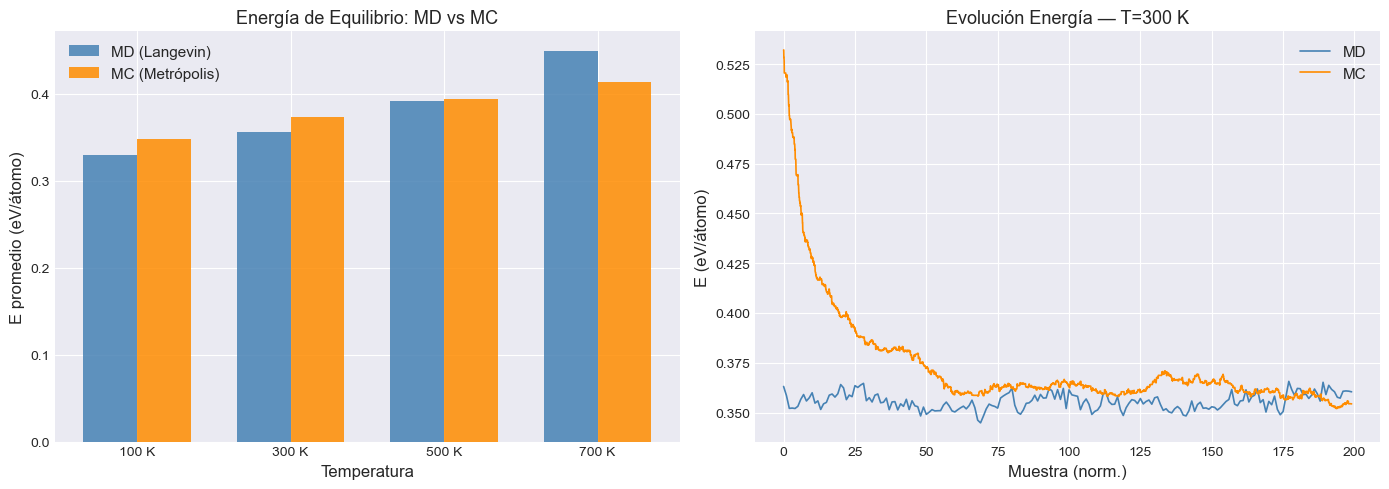

 T (K)   E_MD   E_MC ΔE MC−MD
   100 0.3294 0.3473   0.0178
   300 0.3556 0.3733   0.0177
   500 0.3917 0.3939   0.0022
   700 0.4490 0.4134  -0.0357


In [12]:
e_md_eq = [results[T]['energies'].mean()    for T in TEMPERATURES]
e_mc_eq = [mc_results[T]['energies'].mean() for T in TEMPERATURES]
x = np.arange(len(TEMPERATURES)); w = 0.35
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(x-w/2, e_md_eq, w, label='MD (Langevin)',   color='steelblue',  alpha=0.85)
axes[0].bar(x+w/2, e_mc_eq, w, label='MC (Metrópolis)', color='darkorange', alpha=0.85)
axes[0].set_xticks(x); axes[0].set_xticklabels([f'{T} K' for T in TEMPERATURES])
axes[0].set_xlabel('Temperatura', fontsize=12); axes[0].set_ylabel('E promedio (eV/átomo)', fontsize=12)
axes[0].set_title('Energía de Equilibrio: MD vs MC', fontsize=13); axes[0].legend(fontsize=11)
T_ref = 300; s_md = np.arange(len(results[T_ref]['energies']))
axes[1].plot(s_md, results[T_ref]['energies'], color='steelblue',  lw=1.2, label='MD')
axes[1].plot(np.linspace(0,len(s_md)-1,MC_STEPS), mc_results[T_ref]['energies'],
             color='darkorange', lw=1.2, label='MC')
axes[1].set_title(f'Evolución Energía — T={T_ref} K', fontsize=13)
axes[1].set_xlabel('Muestra (norm.)', fontsize=12); axes[1].set_ylabel('E (eV/átomo)', fontsize=12)
axes[1].legend(fontsize=11)
plt.tight_layout(); plt.savefig('comparacion_energia_md_mc.png', dpi=150); plt.show()
df_comp_e = pd.DataFrame({'T (K)': TEMPERATURES,
    'E_MD': [f'{v:.4f}' for v in e_md_eq], 'E_MC': [f'{v:.4f}' for v in e_mc_eq],
    'ΔE MC−MD': [f'{mc-md:.4f}' for mc,md in zip(e_mc_eq, e_md_eq)]})
print(df_comp_e.to_string(index=False))

## 12. Comparación: Tiempo de Equilibración

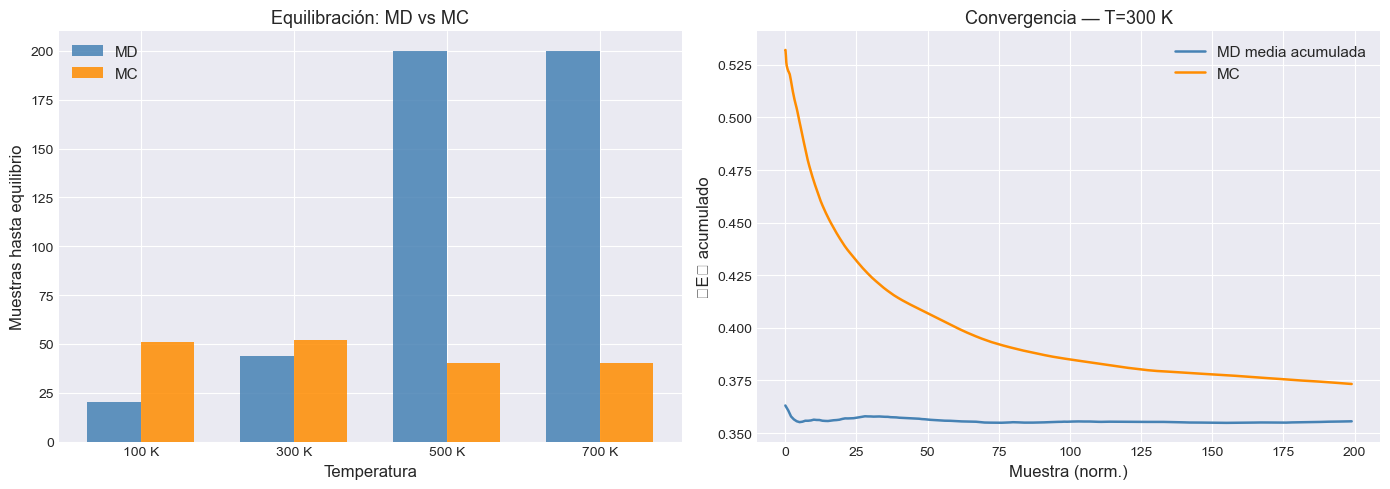

In [13]:
def equilibration_step(energies, window=20, tol=0.002):
    for i in range(window, len(energies)-window):
        if np.std(energies[i:i+window]) < tol: return i
    return len(energies)

equil_md = [equilibration_step(results[T]['energies'])    for T in TEMPERATURES]
equil_mc = [equilibration_step(mc_results[T]['energies']) for T in TEMPERATURES]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(x-w/2, equil_md, w, label='MD', color='steelblue',  alpha=0.85)
axes[0].bar(x+w/2, equil_mc, w, label='MC', color='darkorange', alpha=0.85)
axes[0].set_xticks(x); axes[0].set_xticklabels([f'{T} K' for T in TEMPERATURES])
axes[0].set_xlabel('Temperatura',fontsize=12); axes[0].set_ylabel('Muestras hasta equilibrio',fontsize=12)
axes[0].set_title('Equilibración: MD vs MC',fontsize=13); axes[0].legend(fontsize=11)
cm_md = np.cumsum(results[T_ref]['energies']) / (np.arange(len(results[T_ref]['energies']))+1)
cm_mc = np.cumsum(mc_results[T_ref]['energies']) / (np.arange(len(mc_results[T_ref]['energies']))+1)
axes[1].plot(cm_md, color='steelblue',  lw=1.8, label='MD media acumulada')
axes[1].plot(np.linspace(0,len(cm_md)-1,len(cm_mc)), cm_mc, color='darkorange', lw=1.8, label='MC')
axes[1].set_xlabel('Muestra (norm.)',fontsize=12); axes[1].set_ylabel('⟨E⟩ acumulado',fontsize=12)
axes[1].set_title(f'Convergencia — T={T_ref} K',fontsize=13); axes[1].legend(fontsize=11)
plt.tight_layout(); plt.savefig('equilibracion_md_mc.png', dpi=150); plt.show()

## 13. Comparación: Eficiencia Computacional

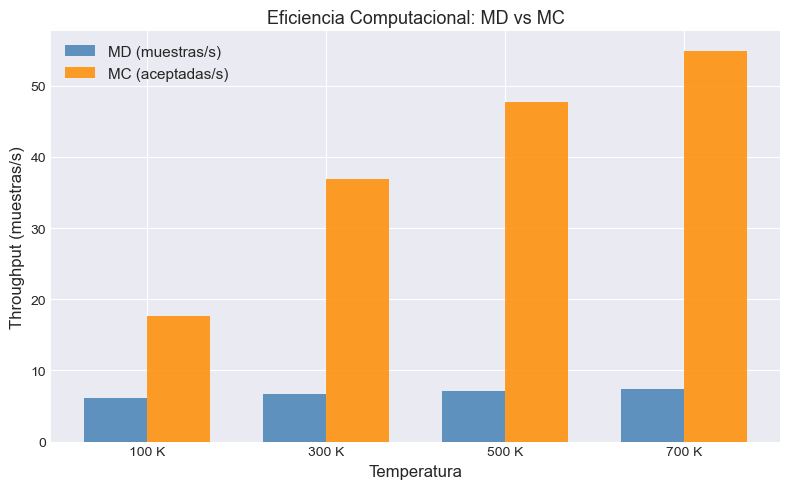

 T (K)   E MD   E MC  Eq MD  Eq MC Efic MD Efic MC Acept MC%
   100 0.3294 0.3473     20     51     6.1    17.7      20.5
   300 0.3556 0.3733     44     52     6.6    36.9      37.6
   500 0.3917 0.3939    200     40     7.1    47.7      47.2
   700 0.4490 0.4134    200     40     7.4    54.9      54.5
Guardado: comparacion_md_mc.csv


In [14]:
eff_md = [len(results[T]['energies'])/md_cpu_times[T] for T in TEMPERATURES]
eff_mc = [int(mc_results[T]['accept_rate']*MC_STEPS)/mc_results[T]['cpu_time'] for T in TEMPERATURES]
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x-w/2, eff_md, w, label='MD (muestras/s)', color='steelblue',  alpha=0.85)
ax.bar(x+w/2, eff_mc, w, label='MC (aceptadas/s)',color='darkorange', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels([f'{T} K' for T in TEMPERATURES])
ax.set_xlabel('Temperatura',fontsize=12); ax.set_ylabel('Throughput (muestras/s)',fontsize=12)
ax.set_title('Eficiencia Computacional: MD vs MC',fontsize=13); ax.legend(fontsize=11)
plt.tight_layout(); plt.savefig('eficiencia_md_mc.png', dpi=150); plt.show()
df_master = pd.DataFrame({'T (K)': TEMPERATURES,
    'E MD': [f'{v:.4f}' for v in e_md_eq], 'E MC': [f'{v:.4f}' for v in e_mc_eq],
    'Eq MD': equil_md, 'Eq MC': equil_mc,
    'Efic MD': [f'{v:.1f}' for v in eff_md], 'Efic MC': [f'{v:.1f}' for v in eff_mc],
    'Acept MC%': [f'{mc_results[T]["accept_rate"]*100:.1f}' for T in TEMPERATURES]})
print(df_master.to_string(index=False))
df_master.to_csv('comparacion_md_mc.csv', index=False)
print('Guardado: comparacion_md_mc.csv')

---
# Tarea 3: Nanofabricación — Crecimiento de Monocapa por MC

## Objetivo
Simular el crecimiento de una monocapa de átomos de Au sobre una superficie cuadrada 2D usando Monte Carlo.
Se estudia el efecto de tres parámetros:
- **Tasa de deposición** (F): átomos depositados por paso de tiempo
- **Temperatura del sustrato** (T): controla la movilidad superficial
- **Energía de enlace** (E_b): interacción átomo–sustrato y átomo–átomo

El algoritmo combina:
1. **Deposición**: átomos caen en posiciones aleatorias de la red
2. **Difusión MC**: cada átomo intenta saltar a un sitio vecino libre con tasa de Metrópolis

## 14. Modelo de crecimiento de monocapa (red cuadrada 2D)

In [15]:
# ── Parámetros del modelo ───────────────────────────────────────────────────
L = 30                   # tamaño de la red (L×L sitios)
kB = 8.617333e-5         # eV/K

# Parámetros de estudio
DEPOSITION_RATES = [0.01, 0.05, 0.20]   # F (fracción de monocapa por paso)
SUBSTRATE_TEMPS  = [300, 500, 700]       # T_sustrato (K)
BINDING_ENERGIES = [0.3, 0.6, 1.0]      # E_b átomo-átomo (eV)

def neighbors_4(i, j, L):
    """Vecinos de primeros orden en red cuadrada con condiciones periódicas."""
    return [((i+1)%L, j), ((i-1)%L, j), (i, (j+1)%L), (i, (j-1)%L)]

def count_occupied_neighbors(grid, i, j, L):
    return sum(1 for ni, nj in neighbors_4(i, j, L) if grid[ni, nj])

def run_monolayer_growth(L=30, F=0.05, T_K=500, E_b=0.6,
                         n_cycles=500, n_mc_per_atom=5, rng=None):
    """
    Simula el crecimiento de monocapa Au sobre sustrato cuadrado 2D.

    Parámetros
    ----------
    L        : int   — lado de la red (L×L sitios)
    F        : float — tasa de dep. (fracción de monocapa por ciclo)
    T_K      : float — temperatura sustrato (K)
    E_b      : float — energía de enlace átomo-átomo (eV)
    n_cycles : int   — ciclos de deposición+difusión
    n_mc_per_atom : int — intentos de difusión por átomo por ciclo

    Retorna: dict con cobertura, energía media, mapa final de la red.
    """
    if rng is None:
        rng = np.random.default_rng(0)
    grid = np.zeros((L, L), dtype=np.int8)   # 0=libre, 1=ocupado
    beta = 1.0 / (kB * T_K)
    n_sites = L * L
    n_deposit_per_cycle = max(1, int(F * n_sites))

    coverage_hist = []
    energy_hist   = []

    for cycle in range(n_cycles):
        # ── Deposición ───────────────────────────────────────────────────
        deposited = 0
        while deposited < n_deposit_per_cycle:
            i, j = rng.integers(0, L, size=2)
            if not grid[i, j]:
                grid[i, j] = 1
                deposited += 1
                if grid.sum() == n_sites:
                    break  # monocapa completa

        # ── Difusión MC ─────────────────────────────────────────────────
        occupied_positions = list(zip(*np.where(grid == 1)))
        rng.shuffle(occupied_positions)
        for (i, j) in occupied_positions:
            for _ in range(n_mc_per_atom):
                # Elegir vecino libre
                nbrs = [(ni, nj) for ni, nj in neighbors_4(i, j, L) if not grid[ni, nj]]
                if not nbrs:
                    continue
                ni, nj = nbrs[rng.integers(len(nbrs))]
                # Calcular ΔE
                E_old = -count_occupied_neighbors(grid, i,  j,  L) * E_b
                grid[i, j] = 0; grid[ni, nj] = 1
                E_new = -count_occupied_neighbors(grid, ni, nj, L) * E_b
                dE = E_new - E_old
                if dE <= 0 or rng.random() < np.exp(-beta * dE):
                    i, j = ni, nj   # aceptar
                else:
                    grid[ni, nj] = 0; grid[i, j] = 1  # revertir

        # ── Registrar ────────────────────────────────────────────────────
        coverage = grid.sum() / n_sites
        occ = list(zip(*np.where(grid == 1)))
        e_mean = (np.mean([-count_occupied_neighbors(grid, i, j, L)*E_b
                            for i, j in occ]) if occ else 0.0)
        coverage_hist.append(coverage)
        energy_hist.append(e_mean)

        if coverage >= 1.0:
            break

    return {'coverage': np.array(coverage_hist),
            'energy':   np.array(energy_hist),
            'grid':     grid.copy(),
            'n_cycles': len(coverage_hist)}

print('Modelo de crecimiento de monocapa definido.')

Modelo de crecimiento de monocapa definido.


## 15. Efecto de la Tasa de Deposición

  F = 0.01 ... cobertura final = 1.00
  F = 0.05 ... cobertura final = 1.00
  F = 0.2 ... cobertura final = 1.00


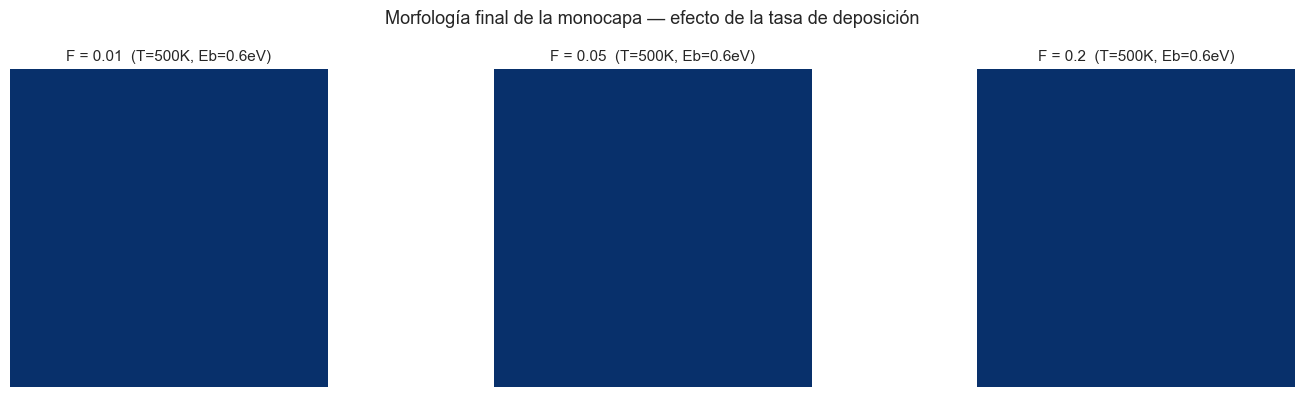

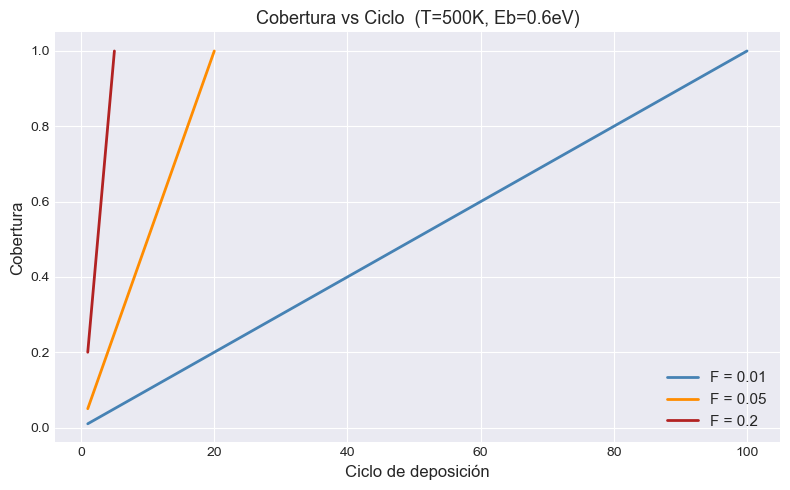

Gráficas guardadas: monocapa_tasa_deposicion.png, cobertura_vs_tasa.png


In [16]:
T_fixed = 500; Eb_fixed = 0.6
res_F = {}
for F in DEPOSITION_RATES:
    print(f'  F = {F} ...', end=' ', flush=True)
    res_F[F] = run_monolayer_growth(L=L, F=F, T_K=T_fixed, E_b=Eb_fixed, n_cycles=500)
    print(f'cobertura final = {res_F[F]["coverage"][-1]:.2f}')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors_F = ['steelblue', 'darkorange', 'firebrick']
for ax, F, col in zip(axes, DEPOSITION_RATES, colors_F):
    ax.imshow(res_F[F]['grid'], cmap='Blues', vmin=0, vmax=1, interpolation='nearest')
    ax.set_title(f'F = {F}  (T={T_fixed}K, Eb={Eb_fixed}eV)', fontsize=11)
    ax.axis('off')
plt.suptitle('Morfología final de la monocapa — efecto de la tasa de deposición', fontsize=13)
plt.tight_layout(); plt.savefig('monocapa_tasa_deposicion.png', dpi=150); plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
for F, col in zip(DEPOSITION_RATES, colors_F):
    cov = res_F[F]['coverage']
    ax.plot(np.arange(1, len(cov)+1), cov, color=col, lw=2, label=f'F = {F}')
ax.set_xlabel('Ciclo de deposición', fontsize=12); ax.set_ylabel('Cobertura', fontsize=12)
ax.set_title(f'Cobertura vs Ciclo  (T={T_fixed}K, Eb={Eb_fixed}eV)', fontsize=13)
ax.legend(fontsize=11); plt.tight_layout()
plt.savefig('cobertura_vs_tasa.png', dpi=150); plt.show()
print('Gráficas guardadas: monocapa_tasa_deposicion.png, cobertura_vs_tasa.png')

## 16. Efecto de la Temperatura del Sustrato

  T = 300 K ... cobertura final = 1.00
  T = 500 K ... cobertura final = 1.00
  T = 700 K ... cobertura final = 1.00


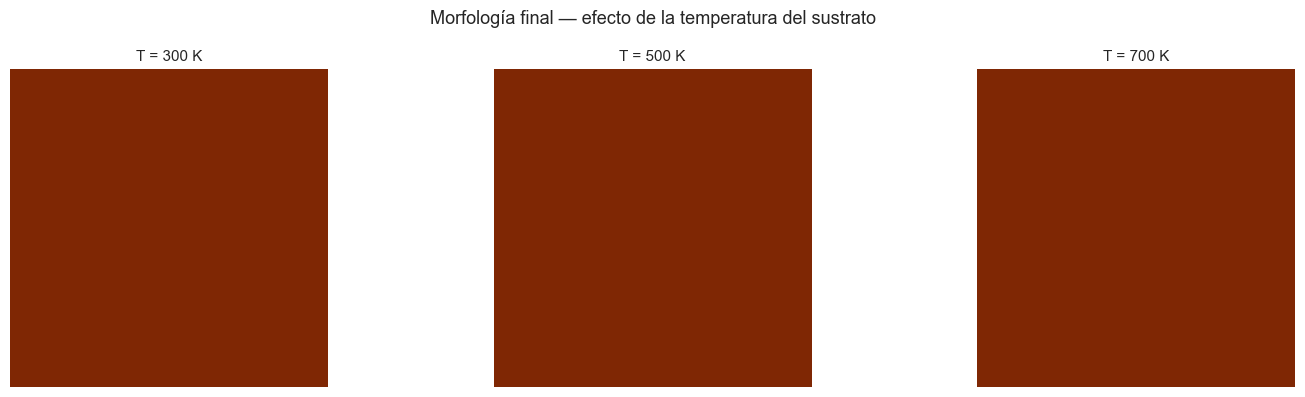

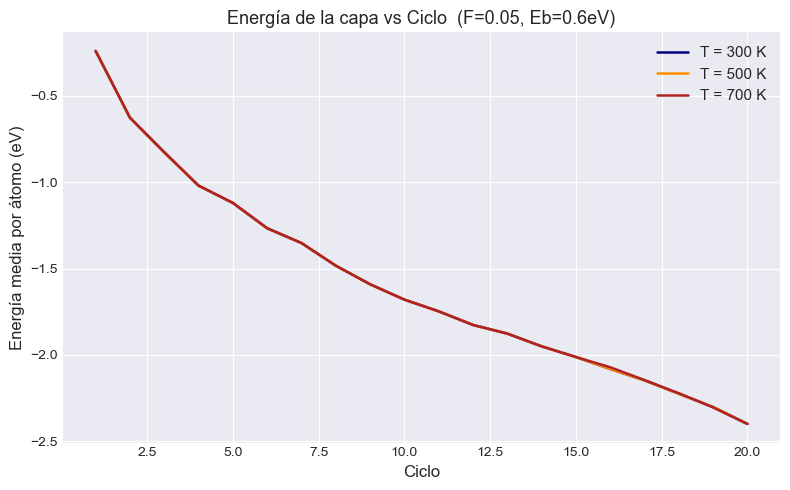

Gráficas guardadas: monocapa_temperatura.png, energia_monocapa_temperatura.png


In [17]:
F_fixed = 0.05
res_T = {}
for T in SUBSTRATE_TEMPS:
    print(f'  T = {T} K ...', end=' ', flush=True)
    res_T[T] = run_monolayer_growth(L=L, F=F_fixed, T_K=T, E_b=Eb_fixed, n_cycles=500)
    print(f'cobertura final = {res_T[T]["coverage"][-1]:.2f}')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors_T = ['navy', 'darkorange', 'firebrick']
for ax, T, col in zip(axes, SUBSTRATE_TEMPS, colors_T):
    ax.imshow(res_T[T]['grid'], cmap='Oranges', vmin=0, vmax=1, interpolation='nearest')
    ax.set_title(f'T = {T} K', fontsize=11); ax.axis('off')
plt.suptitle('Morfología final — efecto de la temperatura del sustrato', fontsize=13)
plt.tight_layout(); plt.savefig('monocapa_temperatura.png', dpi=150); plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
for T, col in zip(SUBSTRATE_TEMPS, colors_T):
    eng = res_T[T]['energy']
    ax.plot(np.arange(1, len(eng)+1), eng, color=col, lw=1.8, label=f'T = {T} K')
ax.set_xlabel('Ciclo', fontsize=12); ax.set_ylabel('Energía media por átomo (eV)', fontsize=12)
ax.set_title(f'Energía de la capa vs Ciclo  (F={F_fixed}, Eb={Eb_fixed}eV)', fontsize=13)
ax.legend(fontsize=11); plt.tight_layout()
plt.savefig('energia_monocapa_temperatura.png', dpi=150); plt.show()
print('Gráficas guardadas: monocapa_temperatura.png, energia_monocapa_temperatura.png')

## 17. Efecto de la Energía de Enlace

  Eb = 0.3 eV ... cobertura final = 1.00
  Eb = 0.6 eV ... cobertura final = 1.00
  Eb = 1.0 eV ... cobertura final = 1.00


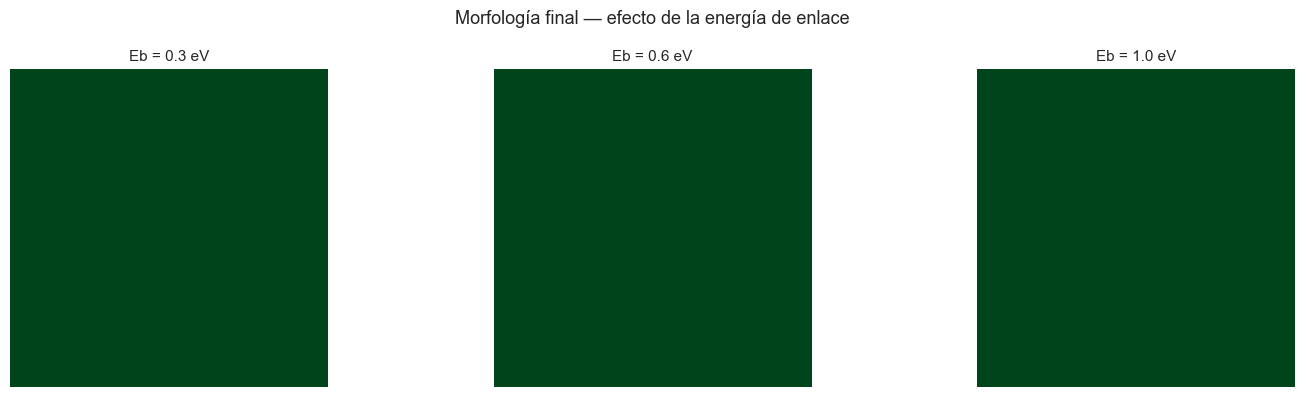

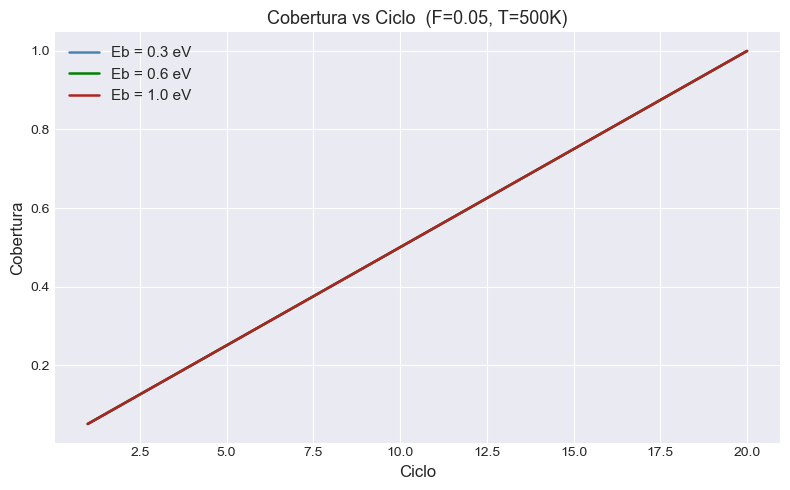

Gráficas guardadas: monocapa_energia_enlace.png, cobertura_vs_enlace.png


In [18]:
T_eb = 500
res_Eb = {}
for Eb in BINDING_ENERGIES:
    print(f'  Eb = {Eb} eV ...', end=' ', flush=True)
    res_Eb[Eb] = run_monolayer_growth(L=L, F=F_fixed, T_K=T_eb, E_b=Eb, n_cycles=500)
    print(f'cobertura final = {res_Eb[Eb]["coverage"][-1]:.2f}')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors_Eb = ['steelblue', 'green', 'firebrick']
for ax, Eb, col in zip(axes, BINDING_ENERGIES, colors_Eb):
    ax.imshow(res_Eb[Eb]['grid'], cmap='Greens', vmin=0, vmax=1, interpolation='nearest')
    ax.set_title(f'Eb = {Eb} eV', fontsize=11); ax.axis('off')
plt.suptitle('Morfología final — efecto de la energía de enlace', fontsize=13)
plt.tight_layout(); plt.savefig('monocapa_energia_enlace.png', dpi=150); plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
for Eb, col in zip(BINDING_ENERGIES, colors_Eb):
    cov = res_Eb[Eb]['coverage']
    ax.plot(np.arange(1, len(cov)+1), cov, color=col, lw=1.8, label=f'Eb = {Eb} eV')
ax.set_xlabel('Ciclo', fontsize=12); ax.set_ylabel('Cobertura', fontsize=12)
ax.set_title(f'Cobertura vs Ciclo  (F={F_fixed}, T={T_eb}K)', fontsize=13)
ax.legend(fontsize=11); plt.tight_layout()
plt.savefig('cobertura_vs_enlace.png', dpi=150); plt.show()
print('Gráficas guardadas: monocapa_energia_enlace.png, cobertura_vs_enlace.png')

## 18. Resumen comparativo — Tarea 3

In [19]:
# Tabla resumen: ciclos hasta cobertura ≥ 90 %
def cycles_to_coverage(cov_array, threshold=0.9):
    idx = np.argmax(cov_array >= threshold)
    return int(idx) if cov_array[idx] >= threshold else len(cov_array)

rows = []
for F in DEPOSITION_RATES:
    rows.append({'Parámetro': f'F = {F}', 'Tipo': 'Tasa dep.',
        'Cobertura final': f'{res_F[F]["coverage"][-1]:.3f}',
        'Ciclos hasta 90%': cycles_to_coverage(res_F[F]['coverage']),
        'E media final (eV/át.)': f'{res_F[F]["energy"][-1]:.3f}'})
for T in SUBSTRATE_TEMPS:
    rows.append({'Parámetro': f'T = {T} K', 'Tipo': 'Temperatura',
        'Cobertura final': f'{res_T[T]["coverage"][-1]:.3f}',
        'Ciclos hasta 90%': cycles_to_coverage(res_T[T]['coverage']),
        'E media final (eV/át.)': f'{res_T[T]["energy"][-1]:.3f}'})
for Eb in BINDING_ENERGIES:
    rows.append({'Parámetro': f'Eb = {Eb} eV', 'Tipo': 'Energía enlace',
        'Cobertura final': f'{res_Eb[Eb]["coverage"][-1]:.3f}',
        'Ciclos hasta 90%': cycles_to_coverage(res_Eb[Eb]['coverage']),
        'E media final (eV/át.)': f'{res_Eb[Eb]["energy"][-1]:.3f}'})

df_t3 = pd.DataFrame(rows)
print('=== Resumen Tarea 3: Nanofabricación — Crecimiento de Monocapa ===')
print(df_t3.to_string(index=False))
df_t3.to_csv('resumen_nanofabricacion.csv', index=False)
print('\nTabla guardada en resumen_nanofabricacion.csv')
print('Archivos generados:')
archivos = ['monocapa_tasa_deposicion.png', 'cobertura_vs_tasa.png',
            'monocapa_temperatura.png', 'energia_monocapa_temperatura.png',
            'monocapa_energia_enlace.png', 'cobertura_vs_enlace.png',
            'resumen_nanofabricacion.csv']
for f in archivos: print(f'  {f}')

=== Resumen Tarea 3: Nanofabricación — Crecimiento de Monocapa ===
  Parámetro           Tipo Cobertura final  Ciclos hasta 90% E media final (eV/át.)
   F = 0.01      Tasa dep.           1.000                89                 -2.400
   F = 0.05      Tasa dep.           1.000                17                 -2.400
    F = 0.2      Tasa dep.           1.000                 4                 -2.400
  T = 300 K    Temperatura           1.000                17                 -2.400
  T = 500 K    Temperatura           1.000                17                 -2.400
  T = 700 K    Temperatura           1.000                17                 -2.400
Eb = 0.3 eV Energía enlace           1.000                17                 -1.200
Eb = 0.6 eV Energía enlace           1.000                17                 -2.400
Eb = 1.0 eV Energía enlace           1.000                17                 -4.000

Tabla guardada en resumen_nanofabricacion.csv
Archivos generados:
  monocapa_tasa_deposicion